# 03. Phase-Boundary & Mechanism Discrimination Analysis

This notebook presents the re-analyzed findings of our **Phase 4 extension**:
- Measurement validity: Cycle-averaged terminal metric $\bar{x}$ and dwell fraction.
- Boundary disappearance: For $C \ge 100$, Adam fails unconditionally across all $\beta_2$.
- Mechanism discrimination: Probes P1 ($\beta_2$ independence) and P2 ($\alpha$ threshold), plus P3 microscopic trace.

---


In [1]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

results_dir = "../results"
df_det = pd.read_csv(os.path.join(results_dir, "deterministic_boundary_cycle_metric.csv"))
df_p1 = pd.read_csv(os.path.join(results_dir, "mechanism_probes", "p1_beta2_sweep.csv"))
df_p2 = pd.read_csv(os.path.join(results_dir, "mechanism_probes", "p2_alpha_sweep.csv"))
with open(os.path.join(results_dir, "phase4_summary_reanalyzed.json"), "r") as f:
    summary = json.load(f)

print("Deterministic Boundary Findings (Cycle-Averaged Metric):")
print(df_det[["C", "status", "k_star", "beta2_star", "x_bar_low_k", "x_bar_high_k"]].to_string())


Deterministic Boundary Findings (Cycle-Averaged Metric):
      C                       status    k_star  beta2_star  x_bar_low_k  x_bar_high_k
0    10  always_survives_no_boundary       NaN         NaN    -0.948639     -0.701732
1    30              genuine_bracket  0.299772    0.990008    -0.514217      0.602782
2   100     always_fails_no_boundary       NaN         NaN     0.173080      0.375504
3   300     always_fails_no_boundary       NaN         NaN     0.585509      0.568642
4  1000     always_fails_no_boundary       NaN         NaN     0.815446      0.746425


## 1. Mechanism Probe P1: $\beta_2$-Independence at Large $C$ ($C=100$)
Notice that as $\beta_2$ increases from $0.99$ to $1 - 10^{-6}$ ($\tau_2 \to 10^6$), the deterministic cycle mean is constant at $+0.173$ and dwell fraction is constant at $0.50$:


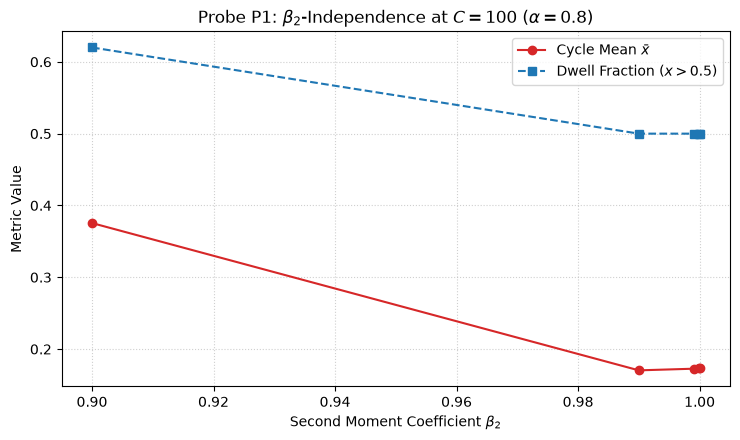

In [2]:
plt.figure(figsize=(7.5, 4.5))
plt.plot(df_p1["beta2"], df_p1["det_mean"], "o-", color="tab:red", label=r"Cycle Mean $\bar{x}$")
plt.plot(df_p1["beta2"], df_p1["det_dwell"], "s--", color="tab:blue", label="Dwell Fraction ($x > 0.5$)")
plt.xlabel(r"Second Moment Coefficient $\beta_2$")
plt.ylabel("Metric Value")
plt.title(r"Probe P1: $\beta_2$-Independence at $C=100$ ($\alpha=0.8$)")
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()


## 2. Mechanism Probe P2: First-Moment Drift Scaling ($\alpha$-Threshold)
Divergence is governed by step size $\alpha$, with a clear transition from survival to failure near $\alpha \approx 0.3$:


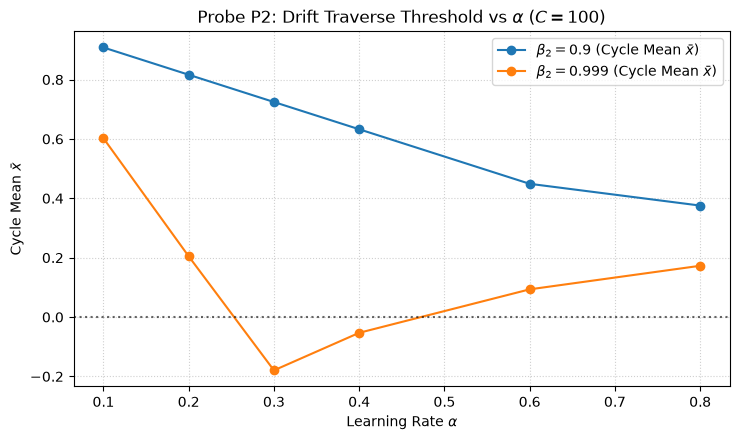

In [3]:
plt.figure(figsize=(7.5, 4.5))
for b2 in [0.9, 0.999]:
    sub = df_p2[df_p2["beta2"] == b2]
    plt.plot(sub["alpha"], sub["det_mean"], "o-", label=r"$\beta_2 = " + str(b2) + r"$ (Cycle Mean $\bar{x}$)")

plt.axhline(0.0, color="k", linestyle=":", alpha=0.6)
plt.xlabel(r"Learning Rate $\alpha$")
plt.ylabel(r"Cycle Mean $\bar{x}$")
plt.title(r"Probe P2: Drift Traverse Threshold vs $\alpha$ ($C=100$)")
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()


## 3. What to Notice & Final Research Verdict
1. **Refutation of Memory-Horizon Hypothesis**: Adam does not follow a simple $C^{-1}$ memory boundary. Beyond $C^* \approx 30$, the boundary ceases to exist because the $C-1$ negative steps drain the first moment negative.
2. **Post-Burst First-Moment Drift**: The true mechanism driving divergence at large $C$ is first-moment saturation ($\tilde{m}_t \approx -1$) accumulating positive drift $\propto \alpha (C - \mathcal{O}(\tau_1))$ that overwhelms the single burst retraction.
